# Absolute Binding Fraction Change Across NREM Bouts: Post-SD vs Control

In [ ]:
#Import Libraries and Setup
import PKA_Sleep as PKA
from PKA_Sleep import Graphing_Utils as graph
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from matplotlib.patches import Patch

graph.make_bigandbold()


In [2]:
# --- Figure saving setup ---
FIG_DIR = '/Users/yaochenlab/Library/CloudStorage/Box-Box/ChenLab/Kane/Figures/Sleep_Deprivation'
SAVE_FORMATS = ['png', 'ps']  # save in all listed formats
SAVE_FIGS = True               # set False to skip saving

def save_fig(fig, name, include_MA, include_REM, delta_mode):
    """Save figure to FIG_DIR with sleep-state and delta-mode info in the filename.
    
    
    include_MA / include_REM default to the notebook globals include_MA / include_REM.
    delta_mode defaults to the notebook global delta_mode.
    Saves once per format in SAVE_FORMATS.
    """
    if not SAVE_FIGS:
        return
    sleep_type = 'sleep' if include_REM else 'nrem'
    transition = 'to_wake' if include_MA else 'to_wake&ma'
    sleep_tag = f'{sleep_type}_{transition}'
    os.makedirs(FIG_DIR, exist_ok=True)
    for fmt in SAVE_FORMATS:
        fname = f'{name}_{sleep_tag}_{delta_mode}.{fmt}'
        fpath = os.path.join(FIG_DIR, fname)
        fig.savefig(fpath, dpi=300, bbox_inches='tight')
        print(f'Saved: {fpath}')

In [ ]:
#Configure Experiment Parameters and Build FLP Classes

parent_data_directory = '/Volumes/yaochen/Active/Lizzie/FLP_data/'
epoch_len = 4
filter_bounds = [None, None]
binned = False
shuffle_window = 200
experimental_sensor = 'FLIM-mAKAR'
sleep_states = True
microarousals = True
seperate_acqs = False

# SD experiments (index 0) and control experiments (index 1)
EXP_NAMES = [
    [
        'kgFLiPAKAREEGEMG0018',
        'kgFLiPAKAREEGEMG0019',
        'kgFLiPAKAREEGEMG0020',
        'kgFLiPAKAREEGEMG0022',
        'kgFLiPAKAREEGEMG0023',
        'kgFLiPAKAREEGEMG0024'
    ],
    [
        'kgFLiPAKAREEGEMG0018',
        'kgFLiPAKAREEGEMG0019',
        'kgFLiPAKAREEGEMG0020',
        'kgFLiPAKAREEGEMG0022',
        'kgFLiPAKAREEGEMG0023',
        'kgFLiPAKAREEGEMG0024'
    ]
]
mouse_names = [
    [
     '5582', 
     '5583', 
     '5577',
     '5576',
     '5580',
     '5710'
     ],
    [
     '5582', 
     '5583', 
     '5577',
     '5576',
     '5580',
     '5710'
     ]
]

# Build FLP classes
FLP_classes_dict = [
    PKA.build_classes(
        e, mouse_names[i], epoch_len=epoch_len, filter_bounds=filter_bounds,
        binned=binned, shuffle_window=shuffle_window, experimental_sensor=experimental_sensor,
        sleep_states=sleep_states, microarousals=microarousals, seperate_acqs=seperate_acqs,
        emp_lifetime=False, parent_data_directory=parent_data_directory, exclude_acqs=False
    )
    for i, e in enumerate(EXP_NAMES)
]

The following acquisisions are not sleep scored:
[np.uint8(11), np.uint8(12), np.uint8(13), np.uint8(49), np.uint8(50)]
I will fill these with 0s
The following acquisisions are not sleep scored:
[np.uint8(49), np.uint8(50)]
I will fill these with 0s
The following acquisisions are not sleep scored:
[np.uint8(46), np.uint8(47), np.uint8(48), np.uint8(49)]
I will fill these with 0s


In [ ]:
#Function for computing mean wake Binding Fraction in a time window
def compute_wake_mean_bf(FLP_exp, window_start, window_end, skip_wake_epochs=10):
    """Compute mean Binding Fraction during wake epochs in a time window,
    excluding the first N sleep-scoring epochs of each wake bout.
    """
    time_mask = (FLP_exp.Time >= window_start) & (FLP_exp.Time <= window_end)
    window_times = FLP_exp.Time[time_mask]
    window_lft = FLP_exp.Lifetime[time_mask]
    if len(window_times) == 0:
        return np.nan
    # Map each photometry sample to the nearest preceding sleep-state epoch
    ss_idx = np.searchsorted(FLP_exp.SSTime, window_times, side='right') - 1
    ss_idx = np.clip(ss_idx, 0, len(FLP_exp.SleepStates) - 1)
    # Build wake-bout position on the full sleep-state vector
    wake_epochs = (FLP_exp.SleepStates == 1)
    wake_pos = np.zeros(len(wake_epochs), dtype=int)
    count = 0
    for i, is_wake in enumerate(wake_epochs):
        if is_wake:
            count += 1
            wake_pos[i] = count
        else:
            count = 0
    # Keep only samples whose matched sleep epoch is past the first N wake epochs
    wake_mask = wake_epochs[ss_idx] & (wake_pos[ss_idx] > skip_wake_epochs)
    if not np.any(wake_mask):
        return np.nan
    return np.mean(window_lft[wake_mask])

def find_zt_window(FLP_exp, zt_start, zt_end, prefer_occurrence=2, gap_threshold=100):
    """Return the index into FLP_exp.Time for the start of the requested ZT window.
    
    If multiple occurrences exist (multi-day recording), returns the
    `prefer_occurrence`-th one (1-indexed), falling back to the last available.
    """
    zeit_mask = (FLP_exp.ZeitTime >= zt_start) & (FLP_exp.ZeitTime <= zt_end)
    if not np.any(zeit_mask):
        return None, 0
    zeit_indices = np.where(zeit_mask)[0]

    # Split into separate occurrences by large gaps in the index array
    gaps = np.diff(zeit_indices)
    gap_locations = np.where(gaps > gap_threshold)[0]
    occurrence_starts = [zeit_indices[0]] + [zeit_indices[g + 1] for g in gap_locations]

    chosen = min(prefer_occurrence, len(occurrence_starts))  # 1-indexed
    occurrence_ends = [zeit_indices[g] for g in gap_locations] + [zeit_indices[-1]]
    return occurrence_starts[chosen - 1], occurrence_ends[chosen - 1], len(occurrence_starts)

#Extract Sleep Bouts for Post-SD and ZT-Matched Control Windows
def extract_sleep_bouts(FLP_exp, window_start, window_end, include_MA, include_REM, exclude_post_MA_epochs):
    """Extract contiguous sleep bouts within a time window.

    REM never breaks a bout boundary (always absorbed for block detection).

    include_REM controls bout filtering:
        False → only keep bouts where first epoch is NREM and last epoch
                is NREM (i.e., Wake→NREM start, NREM→Wake end).  If REM
                appears at the start or end of the block, the entire bout
                is discarded.
        True  → bout onset/offset span the full block (NREM + REM).

    include_MA controls whether MA breaks the bout:
        False → MA ends the current block (+ post-MA epochs excluded)
        True  → MA is absorbed into sleep (no break)

    Returns list of dicts with onset_time, offset_time, onset_idx, offset_idx.
    """
    ss = FLP_exp.SleepStates.copy()
    original_ss = FLP_exp.SleepStates.copy()

    if include_MA:
        ss[ss == 5] = 2
    # Always absorb REM for boundary detection — REM never breaks a bout
    ss[ss == 3] = 2

    is_sleep = (ss == 2).astype(int)
    # Exclude epochs after microarousals
    if not include_MA:
        ma_indices = np.where(original_ss == 5)[0]
        exclude_mask = np.zeros(len(ss), dtype=bool)
        for ma_idx in ma_indices:
            ma_end = ma_idx
            while ma_end < len(ss) - 1 and original_ss[ma_end + 1] == 5:
                ma_end += 1
            for offset in range(1, exclude_post_MA_epochs + 1):
                if ma_end + offset < len(ss):
                    exclude_mask[ma_end + offset] = True
        is_sleep[exclude_mask] = 0

    # Find contiguous sleep bout boundaries
    diff = np.diff(np.concatenate([[0], is_sleep, [0]]))
    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0]

    bouts = []
    for s_idx, e_idx in zip(starts, ends):
        if not include_REM:
            # Only keep bouts where start is NREM and end is NREM→Wake.
            # If REM appears at the start or end of the block, skip the entire bout.
            if original_ss[s_idx] != 2:
                continue  # Block starts with REM, not NREM
            if original_ss[e_idx - 1] != 2:
                continue  # Block ends with REM, not NREM
            actual_start = s_idx
            off_idx = min(e_idx, len(FLP_exp.SSTime) - 1)
        else:
            actual_start = s_idx
            off_idx = min(e_idx, len(FLP_exp.SSTime) - 1)

        onset_time = FLP_exp.SSTime[actual_start]
        offset_time = FLP_exp.SSTime[off_idx]
        if window_start <= onset_time <= window_end:
            bouts.append({
                'onset_idx': actual_start, 'offset_idx': off_idx,
                'onset_time': onset_time, 'offset_time': offset_time
            })
    return bouts

In [ ]:
# ---- Configurable analysis parameters ----
numhours = 6
include_MA = 'both' # True: MA is NREM | only transistions into true wake; False: MA is seperate state | transitions into any arousal; 'both': run both analyses and save with appropriate tags
include_REM = True
exclude_post_MA_epochs = 4
skip_wake_epochs = 8
delta_mode = 'wakeavg'  # 'absolute' or 'wakeavg'

# Resolve include_MA: 'both' runs the analysis once with True and once with
# False; a single bool runs it once. Everything MA-dependent is keyed by these.
include_MA_values = [True, False] if include_MA == 'both' else [include_MA]

# SD window defined by ZT time
sd_zt_start = 0.0          # ZT hour when SD begins
sd_zt_duration_hours = 4.0 # duration of SD period in ZT-hours

sd_info = {}

for i, FLP_exp in enumerate(FLP_classes_dict[0]['Experiment Classes']):
    exp_name = EXP_NAMES[0][i]
    mouse = mouse_names[0][i]
    key = f"{exp_name}_{mouse}"

    sd_zt_end = sd_zt_start + sd_zt_duration_hours

    s_idx = int(find_zt_window(FLP_exp, sd_zt_start, sd_zt_end, prefer_occurrence=2)[0])
    e_idx = int(find_zt_window(FLP_exp, sd_zt_start, sd_zt_end, prefer_occurrence=2)[1])

    sd_start_time = FLP_exp.Time[s_idx]
    sd_end_time   = FLP_exp.Time[e_idx]
    post_sd_start = sd_end_time
    post_sd_end   = sd_end_time + 3600 * numhours

    sd_wake_mean_bf = compute_wake_mean_bf(
        FLP_exp, post_sd_start, post_sd_end, skip_wake_epochs=skip_wake_epochs
    )

    zeit_idx = np.argmin(np.abs(FLP_exp.Time - post_sd_start))
    post_sd_zeit_start = FLP_exp.ZeitTime[zeit_idx]
    post_sd_zeit_end   = post_sd_zeit_start + numhours

    sd_info[key] = {
        'experiment': exp_name, 'mouse': mouse,
        'sd_duration_min': (sd_end_time - sd_start_time) / 60.0,
        'post_sd_start': post_sd_start, 'post_sd_end': post_sd_end,
        'post_sd_zeit_start': post_sd_zeit_start, 'post_sd_zeit_end': post_sd_zeit_end,
        'sd_wake_mean_bf': sd_wake_mean_bf,
        'FLP_exp': FLP_exp
    }


In [ ]:
# --- Extract bouts for each include_MA setting ---
# Bouts depend on include_MA; the control ZT window / wake-mean BF do not.
post_sd_sleep = {ma: {} for ma in include_MA_values}
control_sleep = {ma: {} for ma in include_MA_values}
control_info = {}

# Post-SD bouts
for ma in include_MA_values:
    for key, info in sd_info.items():
        post_sd_sleep[ma][key] = extract_sleep_bouts(
            info['FLP_exp'], info['post_sd_start'], info['post_sd_end'],
            ma, include_REM, exclude_post_MA_epochs
        )

# --- Extract ZT-matched control bouts ---
for i, FLP_exp_ctrl in enumerate(FLP_classes_dict[1]['Experiment Classes']):
    exp_name_ctrl = EXP_NAMES[1][i]
    mouse_ctrl = mouse_names[1][i]
    key_ctrl = f"{exp_name_ctrl}_{mouse_ctrl}"

    # Find matching SD experiments for this mouse
    matching_sd_keys = [k for k, v in sd_info.items() if v['mouse'] == mouse_ctrl]
    if not matching_sd_keys:
        continue

    # Compute this mouse's target ZT window from its SD experiments
    mouse_zt_starts = [sd_info[k]['post_sd_zeit_start'] for k in matching_sd_keys
                       if sd_info[k]['post_sd_zeit_start'] is not None]
    if not mouse_zt_starts:
        continue
    target_zt_start = np.mean(mouse_zt_starts)
    target_zt_end = target_zt_start + numhours

    ctrl_start_idx, _, _ = find_zt_window(
        FLP_exp_ctrl, target_zt_start, target_zt_end, prefer_occurrence=1
    )
    if ctrl_start_idx is None:
        continue

    ctrl_start_time = FLP_exp_ctrl.Time[ctrl_start_idx]
    ctrl_end_time = min(ctrl_start_time + 3600 * numhours, FLP_exp_ctrl.Time[-1])

    ctrl_wake_mean_bf = compute_wake_mean_bf(FLP_exp_ctrl, ctrl_start_time, ctrl_end_time, skip_wake_epochs=skip_wake_epochs)

    control_info[key_ctrl] = {
        'mouse': mouse_ctrl, 'FLP_exp': FLP_exp_ctrl,
        'ctrl_start_time': ctrl_start_time, 'ctrl_end_time': ctrl_end_time,
        'matched_sd_keys': matching_sd_keys,
        'target_zt_start': target_zt_start, 'target_zt_end': target_zt_end,
        'ctrl_wake_mean_bf': ctrl_wake_mean_bf
    }

    # Bouts depend on include_MA
    for ma in include_MA_values:
        control_sleep[ma][key_ctrl] = extract_sleep_bouts(
            FLP_exp_ctrl, ctrl_start_time, ctrl_end_time,
            ma, include_REM, exclude_post_MA_epochs
        )


In [ ]:
#Compute Binding Fraction Change Per Bout

def compute_bout_deltas(FLP_exp, bouts, window_start, mouse_id, numhours,
                        delta_mode='absolute', wake_mean_bf=None):
    """Compute change in Lifetime for each bout.

    delta_mode:
        'absolute':  end − start
        'wakeavg': wake_mean_bf − end

    Returns: deltas, hour_bins, mice (parallel lists)
    """
    deltas, hour_bins, mice = [], [], []
    for bout in bouts:
        bout_mask = (FLP_exp.Time >= bout['onset_time']) & (FLP_exp.Time <= bout['offset_time'])
        if not np.any(bout_mask):
            continue
        lft = FLP_exp.Lifetime[bout_mask]
        if len(lft) < 2:
            continue
        if delta_mode == 'wakeavg':
            if wake_mean_bf is None or np.isnan(wake_mean_bf):
                continue
            delta = lft[-1] - wake_mean_bf
        else:  # 'absolute'
            delta = lft[-1] - lft[0]
        end_time_min = (bout['offset_time'] - window_start) / 60
        hour_bin = int(end_time_min // 60)
        if 0 <= hour_bin < numhours:
            deltas.append(delta)
            hour_bins.append(hour_bin)
            mice.append(mouse_id)
    return deltas, hour_bins, mice


hours = list(range(numhours))
hourly_data = {ma: {'post_sd': {h: [] for h in hours}, 'control': {h: [] for h in hours}}
               for ma in include_MA_values}
hourly_mice = {ma: {'post_sd': {h: [] for h in hours}, 'control': {h: [] for h in hours}}
               for ma in include_MA_values}

for ma in include_MA_values:
    # Post-SD deltas
    for sd_key, bouts in post_sd_sleep[ma].items():
        info = sd_info[sd_key]
        deltas, hbins, mids = compute_bout_deltas(
            info['FLP_exp'], bouts, info['post_sd_start'], info['mouse'], numhours,
            delta_mode=delta_mode, wake_mean_bf=info.get('sd_wake_mean_bf')
        )
        for d, h, m in zip(deltas, hbins, mids):
            hourly_data[ma]['post_sd'][h].append(d)
            hourly_mice[ma]['post_sd'][h].append(m)

    # Control deltas (each control experiment contributes once)
    for key_ctrl, bouts in control_sleep[ma].items():
        ci = control_info[key_ctrl]
        deltas, hbins, mids = compute_bout_deltas(
            ci['FLP_exp'], bouts, ci['ctrl_start_time'], ci['mouse'], numhours,
            delta_mode=delta_mode, wake_mean_bf=ci.get('ctrl_wake_mean_bf')
        )
        for d, h, m in zip(deltas, hbins, mids):
            hourly_data[ma]['control'][h].append(d)
            hourly_mice[ma]['control'][h].append(m)


In [ ]:
#Aggregate Hourly Data by Condition and Mouse

all_mice = {}
mouse_hourly_data = {}

for ma in include_MA_values:
    all_mice[ma] = sorted(set(
        m for h in hours
        for m in hourly_mice[ma]['post_sd'][h] + hourly_mice[ma]['control'][h]
    ))

    mouse_hourly_data[ma] = {
        mouse: {
            'post_sd': {h: [] for h in hours},
            'control': {h: [] for h in hours}
        }
        for mouse in all_mice[ma]
    }

    for condition in ['post_sd', 'control']:
        for h in hours:
            for val, mouse in zip(hourly_data[ma][condition][h], hourly_mice[ma][condition][h]):
                mouse_hourly_data[ma][mouse][condition][h].append(val)


In [ ]:
#Statistical Analysis (Mouse-Level Wilcoxon Signed-Rank)

def get_sig_str(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return 'ns'

stats_results = {ma: {} for ma in include_MA_values}

for ma in include_MA_values:
    print(f"\n=== include_MA={ma} ===")
    for hour in hours:
        print(f"ZT {hour+4}-{hour+5}:", end=" ", flush=True)

        # Mouse-level Wilcoxon signed-rank on per-mouse mean deltas
        means_sd, means_ctrl = [], []
        for mouse in all_mice[ma]:
            sd_vals = mouse_hourly_data[ma][mouse]['post_sd'][hour]
            ct_vals = mouse_hourly_data[ma][mouse]['control'][hour]
            if sd_vals and ct_vals:
                means_sd.append(np.mean(sd_vals))
                means_ctrl.append(np.mean(ct_vals))

        if len(means_sd) >= 2:
            stat, pval = wilcoxon(means_sd, means_ctrl)
            stats_results[ma][hour] = {
                'p_value': pval, 'sig_str': get_sig_str(pval),
                'n_mice': len(means_sd), 'means_sd': means_sd, 'means_ctrl': means_ctrl
            }
            print(f"Wilcoxon W={stat}, p={pval:.4f}")
        else:
            stats_results[ma][hour] = {'p_value': np.nan, 'sig_str': 'na', 'n_mice': len(means_sd)}
            print("Wilcoxon: insufficient mice")

# Print summary
print("\n" + "=" * 60)
print("STATISTICAL RESULTS (Mouse-Level Wilcoxon)")
print("=" * 60)
for ma in include_MA_values:
    print(f"\n--- include_MA={ma} ---")
    for hour in hours:
        ml = stats_results[ma][hour]
        if not np.isnan(ml['p_value']):
            print(f"  ZT {hour+4}-{hour+5}: Wilcoxon p={ml['p_value']:.4f} ({ml['sig_str']}), n={ml['n_mice']}")
        else:
            print(f"  ZT {hour+4}-{hour+5}: Wilcoxon {ml['sig_str']}")



=== include_MA=True ===
ZT 4-5: Wilcoxon W=0.0, p=0.0312
ZT 5-6: Wilcoxon W=0.0, p=0.0312
ZT 6-7: Wilcoxon W=0.0, p=0.0312
ZT 7-8: Wilcoxon W=0.0, p=0.0312
ZT 8-9: Wilcoxon W=10.0, p=1.0000
ZT 9-10: Wilcoxon W=2.0, p=0.0938

=== include_MA=False ===
ZT 4-5: Wilcoxon W=0.0, p=0.0312
ZT 5-6: Wilcoxon W=0.0, p=0.0312
ZT 6-7: Wilcoxon W=0.0, p=0.0312
ZT 7-8: Wilcoxon W=0.0, p=0.0312
ZT 8-9: Wilcoxon W=2.0, p=0.0938
ZT 9-10: Wilcoxon W=1.0, p=0.0625

STATISTICAL RESULTS (Mouse-Level Wilcoxon)

--- include_MA=True ---
  ZT 4-5: Wilcoxon p=0.0312 (*), n=6
  ZT 5-6: Wilcoxon p=0.0312 (*), n=6
  ZT 6-7: Wilcoxon p=0.0312 (*), n=6
  ZT 7-8: Wilcoxon p=0.0312 (*), n=6
  ZT 8-9: Wilcoxon p=1.0000 (ns), n=6
  ZT 9-10: Wilcoxon p=0.0938 (ns), n=6

--- include_MA=False ---
  ZT 4-5: Wilcoxon p=0.0312 (*), n=6
  ZT 5-6: Wilcoxon p=0.0312 (*), n=6
  ZT 6-7: Wilcoxon p=0.0312 (*), n=6
  ZT 7-8: Wilcoxon p=0.0312 (*), n=6
  ZT 8-9: Wilcoxon p=0.0938 (ns), n=6
  ZT 9-10: Wilcoxon p=0.0625 (ns), n=6


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: /Users/yaochenlab/Library/CloudStorage/Box-Box/ChenLab/Kane/Figures/Sleep_Deprivation/hourly_mouse_mean_ladder_sleep_to_wake_wakeavg.png
Saved: /Users/yaochenlab/Library/CloudStorage/Box-Box/ChenLab/Kane/Figures/Sleep_Deprivation/hourly_mouse_mean_ladder_sleep_to_wake_wakeavg.ps


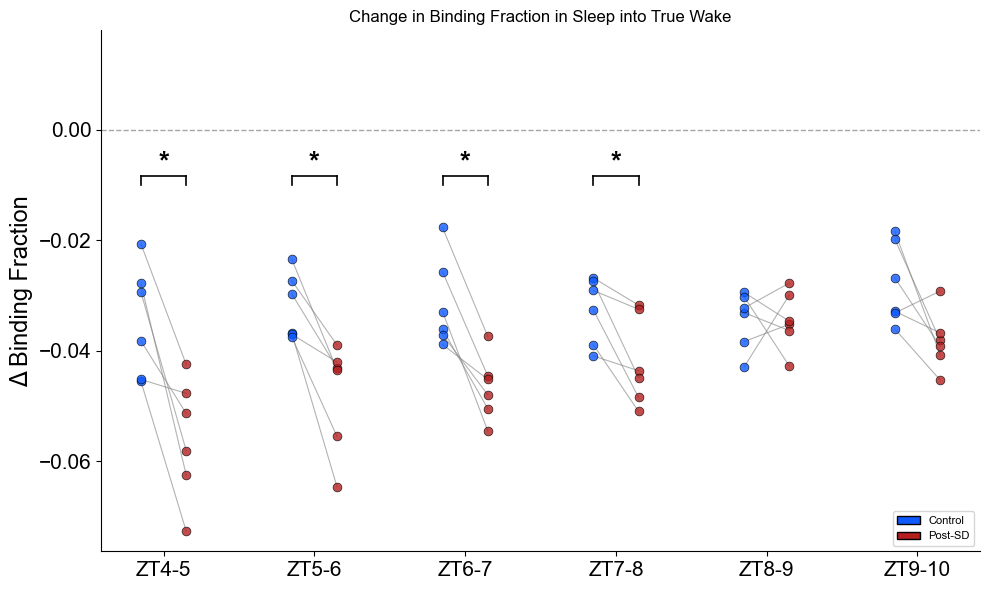

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: /Users/yaochenlab/Library/CloudStorage/Box-Box/ChenLab/Kane/Figures/Sleep_Deprivation/hourly_mouse_mean_ladder_sleep_to_wake&ma_wakeavg.png
Saved: /Users/yaochenlab/Library/CloudStorage/Box-Box/ChenLab/Kane/Figures/Sleep_Deprivation/hourly_mouse_mean_ladder_sleep_to_wake&ma_wakeavg.ps


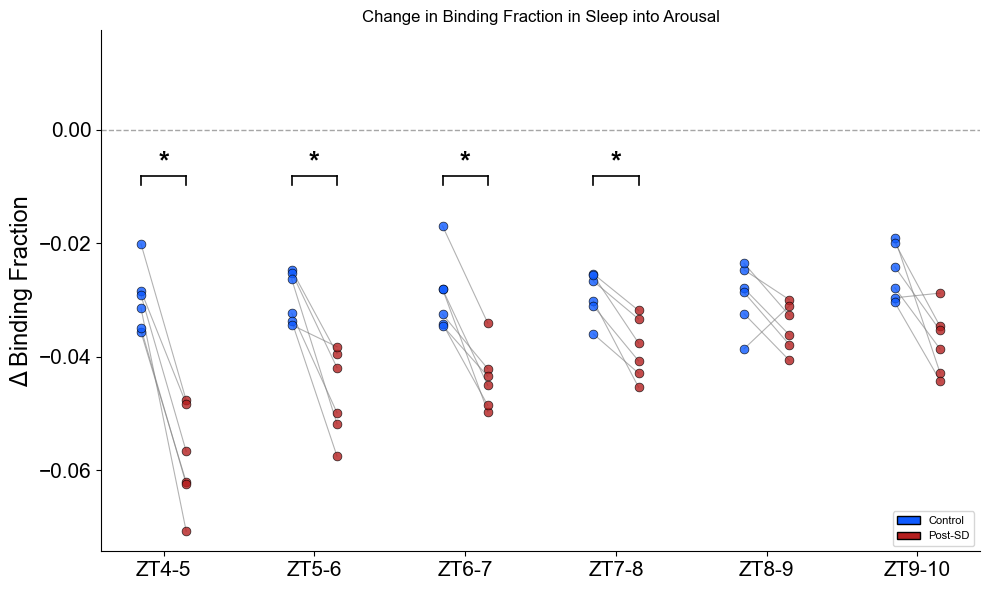

In [16]:
#Hour-by-Hour Mouse-Mean Ladder Plot
# Compute mean ZT start of the post-SD window across all animals for x-axis
zt_starts = [v['post_sd_zeit_start'] for v in sd_info.values() if v['post_sd_zeit_start'] is not None]
mean_zt_start = np.mean(zt_starts) if zt_starts else 0.0
zt_hours = mean_zt_start + np.array(hours)  # ZT value at the start of each hour bin

color_sd, color_ctrl = "#b41f1f", "#0e5aff"
x_ctrl = zt_hours - 0.15
x_sd   = zt_hours + 0.15

def make_ladder(ma):
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))

    for i, hour in enumerate(hours):
        # Draw ladder lines connecting each mouse's control → post-SD
        for mouse in all_mice[ma]:
            ctrl_vals = mouse_hourly_data[ma][mouse]['control'][hour]
            sd_vals   = mouse_hourly_data[ma][mouse]['post_sd'][hour]
            if ctrl_vals and sd_vals:
                y_ctrl = np.mean(ctrl_vals)
                y_sd   = np.mean(sd_vals)
                ax.plot([x_ctrl[i], x_sd[i]], [y_ctrl, y_sd],
                        color='gray', linewidth=0.8, alpha=0.6, zorder=1)

        # Plot individual mouse means per condition
        for condition, x_pos, color in [('control', x_ctrl[i], color_ctrl), ('post_sd', x_sd[i], color_sd)]:
            mouse_means = [
                np.mean(mouse_hourly_data[ma][mouse][condition][hour])
                for mouse in all_mice[ma]
                if mouse_hourly_data[ma][mouse][condition][hour]
            ]
            if len(mouse_means) == 0:
                continue
            mouse_means = np.array(mouse_means)

            # One point per mouse, no jitter
            ax.scatter([x_pos] * len(mouse_means), mouse_means, color=color, alpha=0.8, s=40,
                       edgecolors='k', linewidths=0.5, zorder=2)

    ax.axhline(0, linestyle='--', linewidth=1, color='gray', alpha=0.7)

    # Significance: a bracket spanning control↔post-SD with a single '*' above it,
    # drawn at the same height for every hour (mouse-level Wilcoxon, p < 0.05)
    y_min, y_max = ax.get_ylim()
    y_range = y_max - y_min
    bracket_y = y_max - 0.15 * y_range   # constant height across all hours
    leg = 0.02 * y_range                 # downward tick length at each bracket end

    for i, hour in enumerate(hours):
        p = stats_results[ma][hour]['p_value']
        if not np.isnan(p) and p < 0.05:
            ax.plot([x_ctrl[i], x_sd[i]], [bracket_y, bracket_y], color='black', linewidth=1.2)
            ax.plot([x_ctrl[i], x_ctrl[i]], [bracket_y - leg, bracket_y], color='black', linewidth=1.2)
            ax.plot([x_sd[i], x_sd[i]], [bracket_y - leg, bracket_y], color='black', linewidth=1.2)
            ax.text(zt_hours[i], bracket_y, '*', ha='center', va='bottom',
                    fontsize=20, fontweight='bold', color='black')

    ax.set_ylim(y_min, y_max + 0.18 * y_range)
    ax.set_ylabel('Δ Binding Fraction')
    ax.set_title('Change in Binding Fraction in ' +
                 ('Sleep' if include_REM else 'NREM') + ' into ' +
                 ('True Wake' if ma else 'Arousal'))
    ax.set_xticks(zt_hours)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_xticklabels([f'ZT{zt:.0f}-{zt+1:.0f}' for zt in zt_hours])
    ax.legend(handles=[
        Patch(facecolor=color_ctrl, edgecolor='k', label='Control'),
        Patch(facecolor=color_sd, edgecolor='k', label='Post-SD'),
    ], loc='lower right', fontsize=8)

    plt.tight_layout()
    save_fig(fig, 'hourly_mouse_mean_ladder', include_MA=ma, include_REM=include_REM, delta_mode=delta_mode)
    plt.show()


for ma in include_MA_values:
    make_ladder(ma)
